# Tutorial: Constrained Markov Chain Monte Carlo (MCMC)

This notebook provides a brief tutorial on how to use constrained MCMC samplers within the `QeMCMC` framework. We will demonstrate how to enforce a constraint on the states sampled by both classical and quantum-enhanced MCMC algorithms.

## 1. Set-up and Imports

First, let's import the necessary packages and modules.

In [1]:

import numpy as np
from matplotlib import pyplot as plt
from joblib import Parallel, delayed
from scipy import sparse
import itertools

# Internal imports from our QeMCMC package
from qemcmc.sampler import ClassicalProposal, QeProposal
from qemcmc.sampler.runners import MCMCRunner, ConstrainedMCMCRunner
from qemcmc.utils import plot_chains, get_random_state, ModelMaker
from qemcmc.model import EnergyModel

## 2. Define Model Parameters

Next, we define the parameters for our simulation. We'll use an Ising model with `n=10` spins.

In [27]:
n = 10  # Number of spins in the system
n_spins = n
reps = 5  # How many markov chains to produce
steps = 200  # Length of each markov chain
temp = 0.1  # Temperature of the system



Now, let's create the couplings for our Ising model.

In [28]:
# Make Spin gl[ass Ising model
shape_of_J = (n_spins, n_spins)
J = np.round(np.random.normal(0, 1, shape_of_J), decimals=4)
J_tril = np.tril(J, -1)
J_triu = J_tril.transpose()
J = J_tril + J_triu

h = np.round(np.random.normal(0, 1, n_spins), decimals=4)

couplings = [h, J]
model = EnergyModel(n=n_spins, couplings=couplings)

## 3. Define the Constraint

We'll define a constraint function that accepts a bitstring and returns `True` if the constraint is satisfied, and `False` otherwise. In this example, we'll enforce a zero magnetization constraint, which means that the number of '1's (spin up) must be equal to the number of '0's (spin down).

In [29]:


J_constraint = np.zeros(shape_of_J)
#J_constraint[-2, -1] = 1
#J_constraint[-1, -2] = 1
for i in range(n_spins):
    for j in range(i+1, n_spins):
        u = np.random.uniform(0, 1)
        if u < 0.1:# 10% chance of adding a constraint between these spins
            J_constraint[i, j] = 1
            J_constraint[j, i] = 1
print("Constraint matrix J:\n", J_constraint)
# def zero_magnetization_constraint(bitstring: str) -> bool:
#    """In {0, 1} representation, zero magnetization means sum of bits is n/2"""
#    return bitstring.count('1') == len(bitstring) // 2
def constraint_checker_func(bitstring: str) -> bool:
    """In {0, 1} representation, this constraint means no two adjacent bits can both be 1"""

    sum = 0
    for i in range(len(bitstring)):
        for j in range(i+1, len(bitstring)):
            if bitstring[i] != bitstring[j]:
                sum += J_constraint[i, j]
    return sum == 0

constraint_model = EnergyModel(n=n_spins, couplings=[J_constraint], cost_function_signs=[-1])
# check the function is working as expected
S = ["".join(seq) for seq in itertools.product("01", repeat=n_spins)]
for s in S:
    print(f"Energy: {constraint_model.get_energy(s)}")
    if constraint_checker_func(s):
        print(f"Bitstring {s} satisfies the constraint.")




Constraint matrix J:
 [[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Energy: -2.0
Bitstring 0000000000 satisfies the constraint.
Energy: -2.0
Bitstring 0000000001 satisfies the constraint.
Energy: 0.0
Energy: 0.0
Energy: -2.0
Bitstring 0000000100 satisfies the constraint.
Energy: -2.0
Bitstring 0000000101 satisfies the constraint.
Energy: 0.0
Energy: 0.0
Energy: 0.0
Energy: 0.0
Energy: 2.0
Energy: 2.0
Energy: 0.0
Energy: 0.0
Energy: 2.0
Energy: 2.0
Energy: -2.0
Bitstring 0000010000 satisfies the constraint.
Energy: -2.0
Bitstring 0000010001 satisfies the constraint.
Energy: 0.0
Energy: 0.0
Energy: -2.0
Bitstring 0000010100 satisfies the constraint.
Energy: -2.0
Bitstring 0000010101 satisfies the constraint.

We need to generate initial states that satisfy this constraint.

In [30]:
init_states = []
while len(init_states) < reps:
    state = get_random_state(n_spins)
    if constraint_checker_func(state):
        init_states.append(state)

model.initial_state = init_states
initial_states = model.initial_state
print("Initial states:", initial_states)

Initial states: ['1100011010', '1111111110', '0100001101', '0100101101', '0011110000']


## 4. Run Classical MCMC with Constraints

The `ConstrainedMCMCRunner` is used to run an MCMC simulation with a given constraint. It works by proposing a new state and only accepting it if it satisfies the constraint.

In [31]:
runner = ConstrainedMCMCRunner(model, temp, constraint_checker_func)

### Uniform Method

In [32]:
uni_chains = []
uni_rejections = []
for rep in range(reps):
    classical_uniform_MCMC = ClassicalProposal(model, method="uniform")
    uni_chain, uni_rejection = runner.run(classical_uniform_MCMC, steps, initial_state=initial_states[rep], name="classical uniform MCMC", verbose=False, sample_frequency=1)
    uni_chains.append(uni_chain)
    uni_rejections.append(uni_rejection)


# print average rejections per chain
avg_uni_rejections = np.mean(uni_rejections)/steps
print(f"Average constraint rejections per step: {avg_uni_rejections}")



Average constraint rejections per step: 0.7559999999999999


### Local Method

In [33]:
loc_chains = []
loc_rejections = []
for rep in range(reps):
    classical_local_MCMC = ClassicalProposal(model, method="local")
    loc_chain, loc_rejection = runner.run(classical_local_MCMC, steps, initial_state=initial_states[rep], name="classical local MCMC", verbose=False, sample_frequency=1)
    loc_chains.append(loc_chain)
    loc_rejections.append(loc_rejection)

# print average rejections per chain
avg_loc_rejections = np.mean(loc_rejections)/steps
print(f"Average constraint rejections per step: {avg_loc_rejections}")

Average constraint rejections per step: 0.39299999999999996


## 5. Run Quantum-Enhanced MCMC (QeMCMC) with Constraints

Now we run the quantum-enhanced version. The `QeMCMC` class is very similar to the `ClassicalMCMC` class, but it includes extra parameters specific to the quantum algorithm, like `gamma` and `time`.

In [34]:
# constrained QeMCMC parameters
gamma = (0.3, 0.6)  # Relative strength of mixer hamiltonian
time = (1, 20)  # Time for hamiltonian simulation

both_model = EnergyModel(n=n_spins, couplings=[h, J, J_constraint], cost_function_signs=[1, 1, -1])
coupling_weights = [1, 1, 100]
def run_qemcmc(rep):
    quantum_proposal = QeProposal(both_model, gamma=gamma, time=time, m = 1,coupling_weights = coupling_weights)
    return runner.run(quantum_proposal, steps, initial_state=initial_states[rep], name="QeMCMC", verbose=True, sample_frequency=1)

# Run in parallel as they can take a while.
#output = Parallel(n_jobs=-1)(delayed(run_qemcmc)(rep) for rep in range(reps))
run_qemcmc(0)


Run QeMCMC:   0%|          | 0/200 [00:00<?, ?it/s]

(MCMCChain(), 107)

In [35]:

# QeMCMC parameters
gamma = (0.3, 0.6)  # Relative strength of mixer hamiltonian
time = (1, 20)  # Time for hamiltonian simulation


def run_qemcmc(rep):
    quantum_proposal = QeProposal(model, gamma=gamma, time=time, m = 1)
    return runner.run(quantum_proposal, steps, initial_state=initial_states[rep], name="QeMCMC", verbose=True, sample_frequency=1)

# Run in parallel as they can take a while.
output = Parallel(n_jobs=-1)(delayed(run_qemcmc)(rep) for rep in range(reps))
#run_qemcmc(0)

output = np.array(output)
qe_chains = output[:, 0]
Qe_rejection = output[:, 1]

# print average rejections per chain
avg_rejections = np.mean(Qe_rejection)/steps
print(f"Average constraint rejections per step: {avg_rejections}")

Average constraint rejections per step: 0.748


In [36]:
# constrained QeMCMC parameters
gamma = (0.3,0.6)  # Relative strength of mixer hamiltonian
time = (1, 20)  # Time for hamiltonian simulation
def run_qemcmc(rep):
    quantum_proposal = QeProposal(constraint_model, gamma=gamma, time=time, m = 1)
    return runner.run(quantum_proposal, steps, initial_state=initial_states[rep], name="QeMCMC", verbose=True, sample_frequency=1)

# Run in parallel as they can take a while.
output = Parallel(n_jobs=-1)(delayed(run_qemcmc)(rep) for rep in range(reps))
#run_qemcmc(0)
output = np.array(output)
qe_chains_constr = output[:, 0]
Qe_rejection = output[:, 1]

# print average rejections per chain
avg_rejections = np.mean(Qe_rejection)/steps
print(f"Average constraint rejections per step: {avg_rejections}")

Average constraint rejections per step: 0.272


In [40]:
# constrained QeMCMC parameters
gamma = (0.3, 0.6)  # Relative strength of mixer hamiltonian
time = (1, 20)  # Time for hamiltonian simulation

both_model = EnergyModel(n=n_spins, couplings=[h, J, J_constraint], cost_function_signs=[1, 1, -1])
coupling_weights = [0.3, 0.3, 1]
def run_qemcmc(rep):
    quantum_proposal = QeProposal(both_model, gamma=gamma, time=time, m = 1,coupling_weights = coupling_weights)
    return runner.run(quantum_proposal, steps, initial_state=initial_states[rep], name="QeMCMC", verbose=True, sample_frequency=1)

# Run in parallel as they can take a while.
output = Parallel(n_jobs=-1)(delayed(run_qemcmc)(rep) for rep in range(reps))
#run_qemcmc(0)

output = np.array(output)
qe_chains_both = output[:, 0]
Qe_rejection = output[:, 1]

# print average rejections per chain
avg_rejections = np.mean(Qe_rejection)/steps
print(f"Average constraint rejections per step: {avg_rejections}")

Average constraint rejections per step: 0.312


## 6. Results and Visualization

Finally, we plot the energy evolution of the different chains to compare their performance.

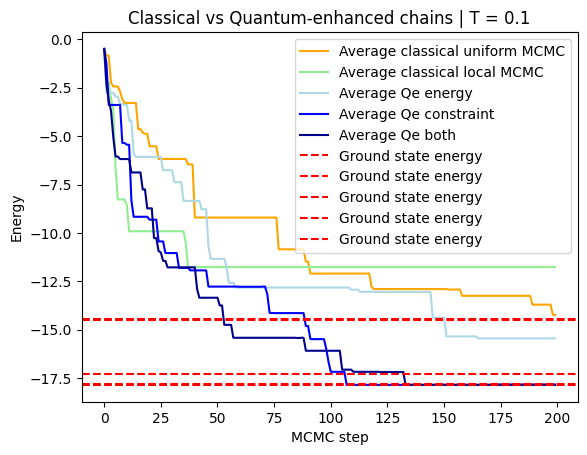

In [41]:
plot_chains(uni_chains, "orange", "classical uniform MCMC", plot_individual_chains=False)
plot_chains(loc_chains, "lightgreen", "classical local MCMC", plot_individual_chains=False)
plot_chains(qe_chains, "lightblue", "Qe energy", plot_individual_chains=False)
plot_chains(qe_chains_constr, "blue", "Qe constraint", plot_individual_chains=False)
plot_chains(qe_chains_both, "darkblue", "Qe both", plot_individual_chains=False)



lowest_energies, degeneracies, lowest_configs = model.get_lowest_energies(20, return_configurations=True)

for i in range(len(lowest_energies)):
    if degeneracies[i] > 1:
        for j in range(degeneracies[i]):
            if constraint_checker_func(lowest_configs[i][j]):
                plt.axhline(lowest_energies[i], color="red", linestyle="--", label=f"Ground state energy (degeneracy {degeneracies[i]})")
    else:
        if constraint_checker_func(lowest_configs[i][0]):
            plt.axhline(lowest_energies[i], color="red", linestyle="--", label="Ground state energy")

plt.xlabel("MCMC step")
plt.ylabel("Energy")
plt.title("Classical vs Quantum-enhanced chains | T = {}".format(temp))
plt.legend()
plt.show()

# Bonus: Coarse graining

As a wee bonus, we include the functionality for doing larger constrained systems, with coarse graining. When the state space is too large, we can use coarse-graining to reduce the number of states. This is done by grouping states together. The MCMC is then run on this smaller, coarse-grained state space.



In [1]:

import numpy as np
from matplotlib import pyplot as plt
from joblib import Parallel, delayed
from scipy import sparse
import itertools

# Internal imports from our QeMCMC package
from qemcmc.sampler import ClassicalProposal, QeProposal
from qemcmc.sampler.runners import MCMCRunner, ConstrainedMCMCRunner
from qemcmc.utils import plot_chains, get_random_state, ModelMaker
from qemcmc.model import EnergyModel

In [ ]:
# Import the CoarseGraining class
from qemcmc.coarse_grain import CoarseGraining

# Define a larger system
n_large = 20
steps_large = 100
reps = 5
temp =0.1
model_large = ModelMaker(n_large, "Fully Connected Ising", "large model").model

shape_of_J = (n_large, n_large)
J_constraint = np.zeros(shape_of_J)
for i in range(n_large):
    for j in range(i+1, n_large):
        u = np.random.uniform(0, 1)
        if u < 0.01:# 10% chance of adding a constraint between these spins
            J_constraint[i, j] = 1
            J_constraint[j, i] = 1

large_model_constraint = EnergyModel(n=n_large, couplings=[J_constraint], cost_function_signs=[-1])

def constraint_checker_func(bitstring: str) -> bool:
    """In {0, 1} representation, this constraint means no two adjacent bits can both be 1"""

    sum = 0
    for i in range(len(bitstring)):
        for j in range(i+1, len(bitstring)):
            if bitstring[i] != bitstring[j]:
                sum += J_constraint[i, j]
    return sum == 0


init_states = []
while len(init_states) < reps:
    state = get_random_state(n_large)
    if constraint_checker_func(state):
        init_states.append(state)

model_large.initial_state = init_states
initial_states = model_large.initial_state
print("Initial states:", initial_states)

runner_large = ConstrainedMCMCRunner(large_model_constraint, temp, constraint_checker_func)


Initial states: ['00000111100010101111', '01000111110110110101', '00101001000011011000', '01010111000111110111', '11010001010110110010']


In [6]:
gamma = (0.3, 0.6)  # Relative strength of mixer hamiltonian
time = (1, 20)  # Time for hamiltonian simulation


large_model_both = EnergyModel(n=n_large, couplings=model_large.couplings + [J_constraint], cost_function_signs=[1, 1, -1])
coupling_weights = [0.1, 0.1, 1]

def run_qemcmc_large(rep):
    quantum_proposal = QeProposal(model_large, gamma=gamma, time=time, m = 2)
    return runner_large.run(quantum_proposal, steps_large, initial_state=initial_states[rep], name="QeMCMC", verbose=True, sample_frequency=1)

# Run in parallel as they can take a while.
output = Parallel(n_jobs=-1)(delayed(run_qemcmc_large)(rep) for rep in range(reps))
output = np.array(output)
large_qe_chains_both = output[:, 0]
large_qe_rejection = output[:, 1]

# print average rejections per chain
avg_rejections = np.mean(large_qe_rejection)/steps_large
print(f"Average constraint rejections per step: {avg_rejections}")




Average constraint rejections per step: 0.642


In [ ]:
steps_large = 10000

uni_chains_large = []
for rep in range(reps):
    classical_uniform_proposal = ClassicalProposal(model_large, method="uniform")
    uni_chain, uni_rejection = runner_large.run(classical_uniform_proposal, steps_large, initial_state=initial_states[rep], name="classical uniform MCMC", verbose=False, sample_frequency=1)
    uni_chains_large.append(uni_chain)
print("uniform constraint rejection rate:", np.mean(uni_rejection)/steps_large)
loc_chains_large = []
for rep in range(reps):
    classical_local_proposal = ClassicalProposal(model_large, method="2-local")
    loc_chain, loc_rejection = runner_large.run(classical_local_proposal, steps_large, initial_state=initial_states[rep], name="classical 2-local MCMC", verbose=False, sample_frequency=1)
    loc_chains_large.append(loc_chain)
print("local constraint rejection rate:", np.mean(loc_rejection)/steps_large)

uniform rejection rate: 0.7524
local rejection rate: 0.2803


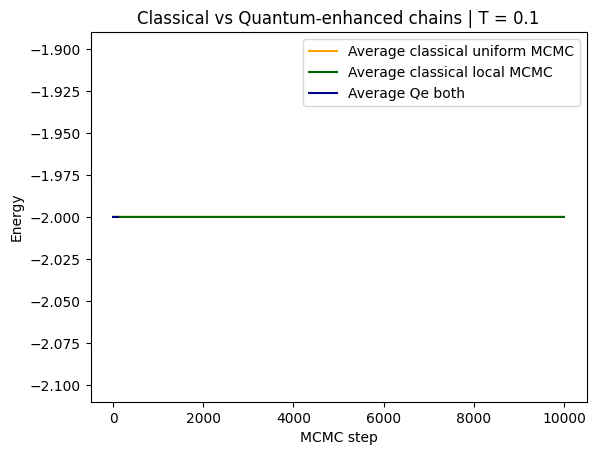

In [10]:
plot_chains(uni_chains_large, "orange", "classical uniform MCMC", plot_individual_chains=False)
plot_chains(loc_chains_large, "darkgreen", "classical local MCMC", plot_individual_chains=False)
plot_chains(large_qe_chains_both, "darkblue", "Qe both", plot_individual_chains=False)



plt.xlabel("MCMC step")
plt.ylabel("Energy")
plt.title("Classical vs Quantum-enhanced chains | T = {}".format(temp))
plt.legend()
plt.show()